In [1]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

In [2]:
train_folder_path_x = "/kaggle/input/cv-project-data/low_resolution"
train_folder_path_y = "/kaggle/input/cv-project-data/high_resolution"
train_tuple = []
test_tuple = []

class MyDataLoader():
    def make_training_data(self):
        for f in os.listdir(train_folder_path_x):
            image_path_x = os.path.join(train_folder_path_x, f)
            image_path_y = os.path.join(train_folder_path_y, f)

            image_x = cv2.imread(image_path_x)

            image_y = cv2.imread(image_path_y)
            train_tuple.append((image_x,image_y))
                
dataLoader = MyDataLoader()
dataLoader.make_training_data()

In [3]:
print(len(train_tuple))
print((train_tuple[20][0]).shape)
print((train_tuple[20][1]).shape)

900
(128, 128, 3)
(512, 512, 3)


In [ ]:
def plot_images(index):
    img1 = train_tuple[index][0]
    img2 = train_tuple[index][1]
    
    # Get dimensions
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    
    # Create figure big enough to hold both images
    fig = plt.figure(figsize=((w1 + w2) / 100, max(h1, h2) / 100))
    
    # Axes for first image
    ax1 = fig.add_axes([0, 0, w1 / (w1 + w2), 1])  # [left, bottom, width, height] in 0-1 range
    ax1.imshow(img1)
    ax1.axis('off')
    
    # Axes for second image
    ax2 = fig.add_axes([w1 / (w1 + w2), 0, w2 / (w1 + w2), 1])
    ax2.imshow(img2)
    ax2.axis('off')
    
    plt.show()

In [ ]:
plot_images(1)

In [4]:
def upsample_lancros(image_x,scale=4):
    h, w = image_x.shape[:2]
    new_w, new_h = int(w * scale), int(h * scale)

    # Upsample using Lanczos interpolation
    pred = cv2.resize(image_x, (new_w, new_h), interpolation=cv2.INTER_LANCZOS4)
    return pred

In [ ]:
# def lanczos_kernel(x, a):
#     """Lanczos kernel function."""
#     if x == 0:
#         return 1
#     elif -a < x < a:
#         return a * np.sinc(x) * np.sinc(x / a)
#     else:
#         return 0

# def upsample_lancros2(image, scale=4, a=3):
#     """
#     Upsample an image using Lanczos interpolation.
    
#     Parameters:
#         image: numpy array (grayscale or RGB)
#         scale: scaling factor (default 4x)
#         a: size of Lanczos window (default 3)

#     Returns:
#         Upsampled image as numpy array.
#     """
#     if image.ndim == 2:  # Grayscale
#         h, w = image.shape
#         channels = 1
#     else:  # RGB
#         h, w, channels = image.shape

#     new_h, new_w = int(h * scale), int(w * scale)
#     output = np.zeros((new_h, new_w, channels)) if channels > 1 else np.zeros((new_h, new_w))

#     for y_new in range(new_h):
#         for x_new in range(new_w):
#             print(y_new,x_new)
#             # Map new pixel to original image space
#             x_orig = x_new / scale
#             y_orig = y_new / scale

#             x0 = int(np.floor(x_orig))
#             y0 = int(np.floor(y_orig))

#             # Accumulators
#             pixel = np.zeros(channels) if channels > 1 else 0.0
#             norm = 0.0

#             for j in range(y0 - a + 1, y0 + a + 1):
#                 for i in range(x0 - a + 1, x0 + a + 1):
#                     if 0 <= i < w and 0 <= j < h:
#                         wx = lanczos_kernel(x_orig - i, a)
#                         wy = lanczos_kernel(y_orig - j, a)
#                         weight = wx * wy
#                         if channels > 1:
#                             pixel += image[j, i] * weight
#                         else:
#                             pixel += image[j, i] * weight
#                         norm += weight

#             if norm > 0:
#                 output[y_new, x_new] = pixel / norm

#     if channels == 1:
#         output = output.astype(image.dtype)
#     else:
#         output = output.clip(0, 255).astype(image.dtype)

#     return output

In [20]:
def loss_and_y_pred():
    l1_total = 0
    l2_total = 0
    psnr=0
    ssim=0

    for x_train, y_train in train_tuple:
        pred = upsample_lancros(x_train)

        pred = np.array(pred)
        y_train = np.array(y_train)
        l1_loss = np.mean(np.abs(pred - y_train))
        l2_loss = np.mean((pred - y_train) ** 2)
        
        psnr += peak_signal_noise_ratio(y_train, pred, data_range=255)
        ssim += structural_similarity(y_train, pred, channel_axis=-1, data_range=255)
        l1_total += l1_loss
        l2_total += l2_loss

    l1_avg = l1_total / len(train_tuple)
    l2_avg = l2_total / len(train_tuple)
    psnr_avg = psnr / len(train_tuple)
    ssim_avg = ssim / len(train_tuple)
    return l1_avg, l2_avg, psnr_avg, ssim_avg

In [21]:
l1_avg, l2_avg, psnr_avg, ssim_avg = loss_and_y_pred()

In [23]:
print("l1_loss: ",l1_avg)
print("l2_loss: ",l2_avg)
print("psnr_avg: ",psnr_avg)
print("ssim_avg: ",ssim_avg)

l1_loss:  76.36764337327749
l2_loss:  41.1257448380082
psnr_avg:  22.51116216761795
ssim_avg:  0.712527004106931


In [6]:
def visualize(index):
    x_train = train_tuple[index][0]
    y_pred = upsample_lancros(x_train)
    y_train = train_tuple[index][1]
    
    # Get dimensions
    h1, w1 = x_train.shape[:2]
    h2, w2 = y_pred.shape[:2]
    h3, w3 = y_train.shape[:2]
    
    # Create figure big enough to hold both images
    fig = plt.figure(figsize=((w1 + w2 + w3) / 100, max(h1, h2, h3) / 100))
    
    # Axes for first image
    ax1 = fig.add_axes([0, 0, w1 / (w1 + w2 + w3), 1])  # [left, bottom, width, height] in 0-1 range
    ax1.imshow(x_train)
    ax1.axis('off')
    
    # Axes for second image
    ax2 = fig.add_axes([w1 / (w1 + w2 + w3), 0, w2 / (w1 + w2 + w3), 1])
    ax2.imshow(y_pred)
    ax2.axis('off')
    
    # # Axes for third image
    ax3 = fig.add_axes([(w2+w1) / (w1 + w2 + w3), 0, w3 / (w1 + w2 + w3), 1])
    ax3.imshow(y_train)
    ax3.axis('off')
    
    plt.show()

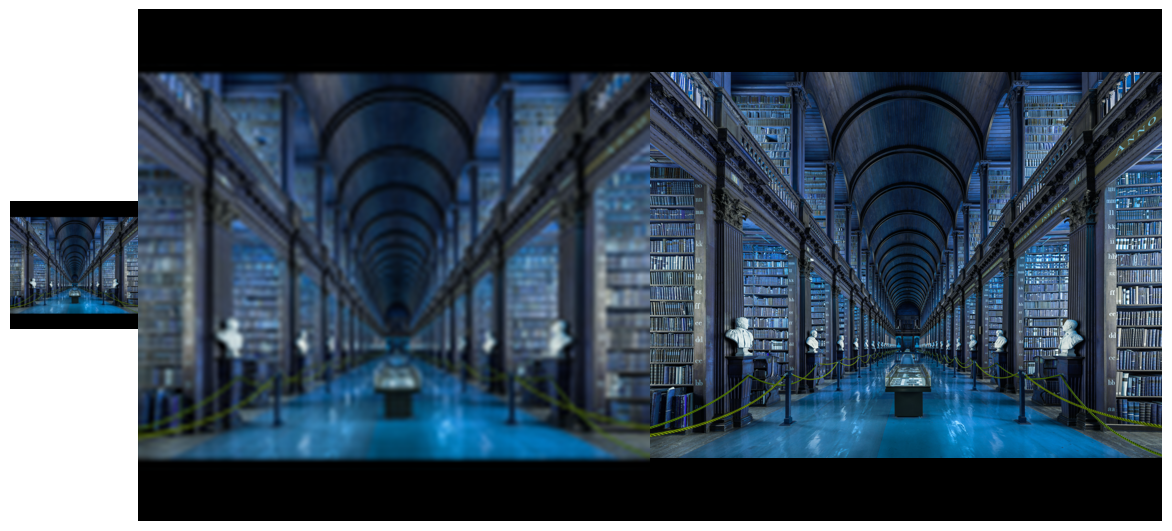

In [8]:
visualize(10)

In [9]:
index=50

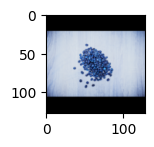

In [10]:
x_train = train_tuple[index][0]
h, w = x_train.shape[:2]
fig = plt.figure(figsize=(w / 100, h / 100))  # Scale by DPI or just by a factor
plt.imshow(x_train)
plt.show()

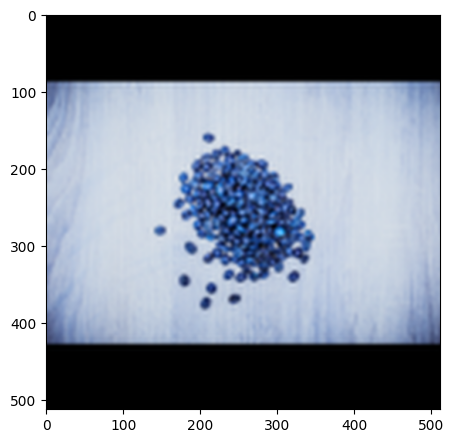

In [11]:
y_pred =  upsample_lancros(train_tuple[index][0])
h, w = y_pred.shape[:2]
fig = plt.figure(figsize=(w / 100, h / 100))  # Scale by DPI or just by a factor
plt.imshow(y_pred)
plt.show()

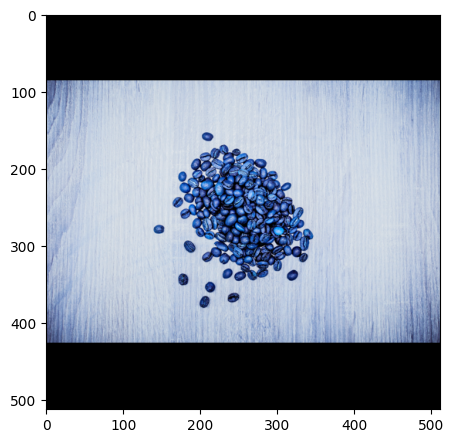

In [12]:
y_train = train_tuple[index][1]
h, w = y_train.shape[:2]
fig = plt.figure(figsize=(w / 100, h / 100))  # Scale by DPI or just by a factor
plt.imshow(y_train)
plt.show()

In [5]:
def vis_2(index):

    # Assuming x_train, y_pred, and y_train are the images you want to display
    x_train = train_tuple[index][0]
    y_pred = upsample_lancros(x_train)
    y_train = train_tuple[index][1]
    
    # Create a figure with 1 row and 3 columns
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    
    # Plot the images
    axs[0].imshow(x_train, cmap='gray')
    axs[0].set_title('x_train')
    axs[0].axis('off')  # Turn off axis
    
    axs[1].imshow(y_pred, cmap='gray')
    axs[1].set_title('y_pred')
    axs[1].axis('off')  # Turn off axis
    
    axs[2].imshow(y_train, cmap='gray')
    axs[2].set_title('y_train')
    axs[2].axis('off')  # Turn off axis
    
    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()


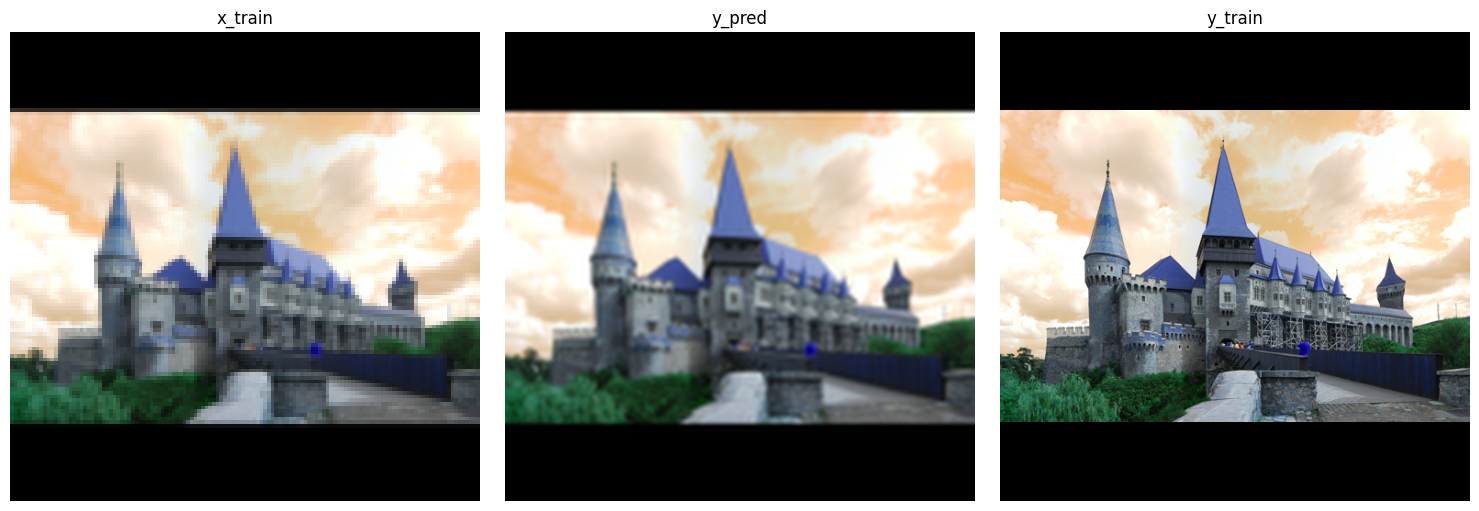

In [7]:
vis_2(700)